In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

U, s, Vh = np.linalg.svd(A, full_matrices=False)
S = np.diag(s)

print("U", U.shape)
print("s", S.shape)
print("Vh", Vh.shape)

U (3, 2)
s (2, 2)
Vh (2, 2)


In [6]:
A_reconstructed = U @ S @ Vh
print("A reconstructed\n", A_reconstructed)

A reconstructed
 [[1. 2.]
 [3. 4.]
 [5. 6.]]



--- i = 1 ---
v =
[-0.61962948 -0.78489445]
u =
[-0.2298477  -0.52474482 -0.81964194]
lambda = 90.7354949127342
sqrt(lambda) = 9.52551809156511
A @ v =
[-2.18941839 -4.99846626 -7.80751414]
sqrt(lambda) * u =
[-2.18941839 -4.99846626 -7.80751414]
same = True

--- i = 2 ---
v =
[-0.78489445  0.61962948]
u =
[ 0.88346102  0.24078249 -0.40189603]
lambda = 0.2645050872658187
sqrt(lambda) = 0.5143005806586443
A @ v =
[ 0.45436451  0.12383458 -0.20669536]
sqrt(lambda) * u =
[ 0.45436451  0.12383458 -0.20669536]
same = True


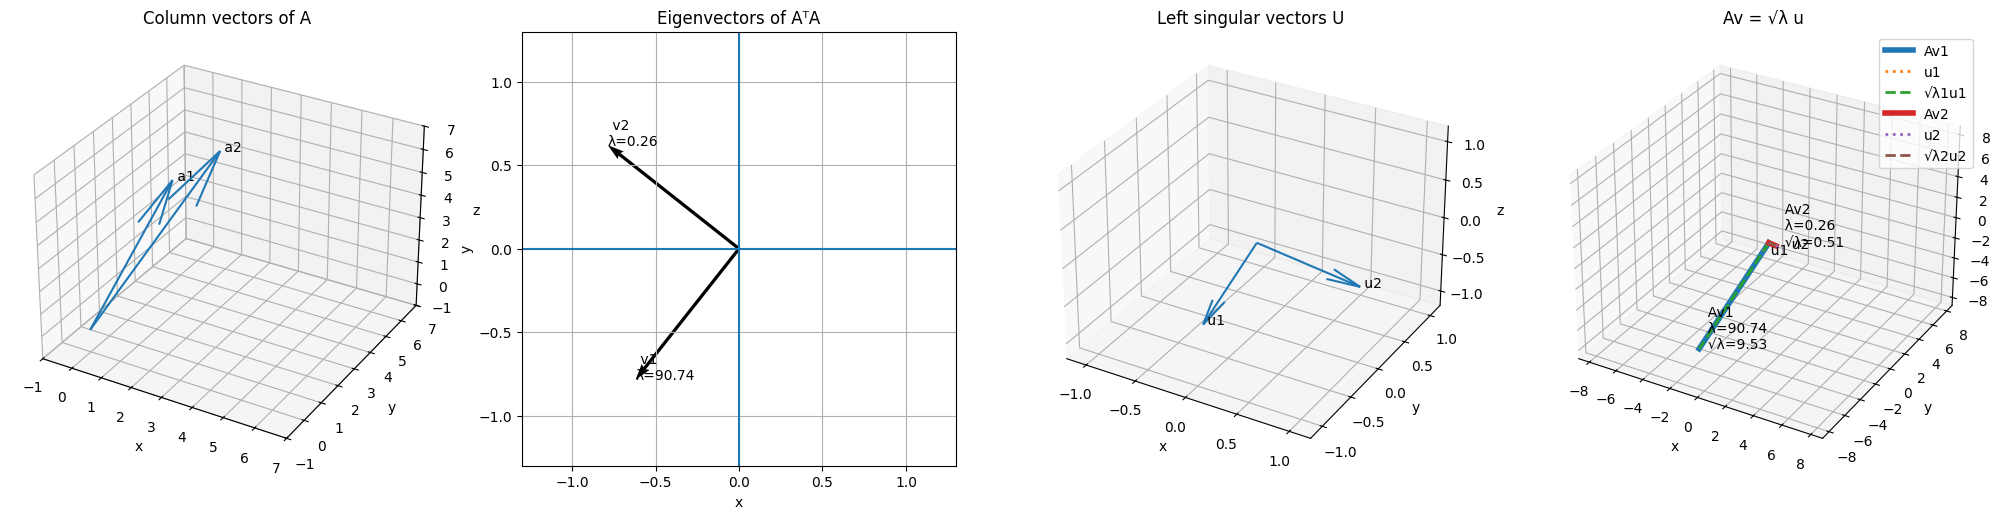

In [7]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

# =========================================================
# 1. eig(A^T A)
# =========================================================
eigenvalues, V = np.linalg.eigh(A.T @ A)

# 큰 eigenvalue 순으로 정렬
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
V = V[:, idx]

# =========================================================
# 2. SVD
# =========================================================
U, s, Vh = np.linalg.svd(A, full_matrices=False)
V_svd = Vh.T

# 부호 맞추기
for i in range(2):
    if np.dot(V[:, i], V_svd[:, i]) < 0:
        V[:, i] *= -1
    if np.dot(U[:, i], A @ V[:, i]) < 0:
        U[:, i] *= -1

fig = plt.figure(figsize=(20, 5))

# =========================================================
# 3. A의 column vectors
# =========================================================
ax1 = fig.add_subplot(1, 4, 1, projection="3d")

a1 = A[:, 0]
a2 = A[:, 1]

ax1.quiver(0, 0, 0, a1[0], a1[1], a1[2])
ax1.quiver(0, 0, 0, a2[0], a2[1], a2[2])

ax1.text(a1[0], a1[1], a1[2], " a1")
ax1.text(a2[0], a2[1], a2[2], " a2")

ax1.set_xlim(-1, 7)
ax1.set_ylim(-1, 7)
ax1.set_zlim(-1, 7)

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Column vectors of A")

# =========================================================
# 4. Eigenvectors v of A^T A
# =========================================================
ax2 = fig.add_subplot(1, 4, 2)

for i in range(2):
    v = V[:, i]
    ax2.quiver(
        0, 0,
        v[0], v[1],
        angles="xy",
        scale_units="xy",
        scale=1
    )
    ax2.text(
        v[0], v[1],
        f" v{i+1}\nλ={eigenvalues[i]:.2f}"
    )

ax2.axhline(0)
ax2.axvline(0)
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-1.3, 1.3)
ax2.set_aspect("equal")
ax2.grid(True)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Eigenvectors of AᵀA")

# =========================================================
# 5. U vectors (unit direction vectors)
# =========================================================
ax3 = fig.add_subplot(1, 4, 3, projection="3d")

for i in range(2):
    u = U[:, i]
    ax3.quiver(0, 0, 0, u[0], u[1], u[2])
    ax3.text(u[0], u[1], u[2], f" u{i+1}")

ax3.set_xlim(-1.2, 1.2)
ax3.set_ylim(-1.2, 1.2)
ax3.set_zlim(-1.2, 1.2)

ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.set_title("Left singular vectors U")

# =========================================================
# 6. Compare Av, u, sqrt(lambda)u
# =========================================================
ax4 = fig.add_subplot(1, 4, 4, projection="3d")

all_vecs = []

for i in range(2):
    lam = eigenvalues[i]
    sigma = np.sqrt(lam)

    v = V[:, i]
    u = U[:, i]

    Av = A @ v
    sigma_u = sigma * u

    all_vecs.append(Av)
    all_vecs.append(sigma_u)
    all_vecs.append(u)

    # Av
    ax4.plot(
        [0, Av[0]],
        [0, Av[1]],
        [0, Av[2]],
        linewidth=4,
        label=f"Av{i+1}"
    )

    # u (unit direction)
    ax4.plot(
        [0, u[0]],
        [0, u[1]],
        [0, u[2]],
        ":",
        linewidth=2,
        label=f"u{i+1}"
    )

    # sqrt(lambda)u
    ax4.plot(
        [0, sigma_u[0]],
        [0, sigma_u[1]],
        [0, sigma_u[2]],
        "--",
        linewidth=2,
        label=f"√λ{i+1}u{i+1}"
    )

    ax4.text(
        Av[0], Av[1], Av[2],
        f"  Av{i+1}\n"
        f"  λ={lam:.2f}\n"
        f"  √λ={sigma:.2f}"
    )

    ax4.text(
        u[0], u[1], u[2],
        f"  u{i+1}"
    )

    print(f"\n--- i = {i+1} ---")
    print("v =")
    print(v)
    print("u =")
    print(u)
    print("lambda =", lam)
    print("sqrt(lambda) =", sigma)
    print("A @ v =")
    print(Av)
    print("sqrt(lambda) * u =")
    print(sigma_u)
    print("same =", np.allclose(Av, sigma_u))

# 축 범위 자동 비슷하게
all_vecs = np.array(all_vecs)
m = np.max(np.abs(all_vecs)) + 1

ax4.set_xlim(-m, m)
ax4.set_ylim(-m, m)
ax4.set_zlim(-m, m)

ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_zlabel("z")
ax4.set_title("Av = √λ u")
ax4.legend()

plt.tight_layout()
plt.show()


--- i = 1 ---
v =
[-0.61962948 -0.78489445]
u =
[-0.2298477  -0.52474482 -0.81964194]
A @ v =
[-2.18941839 -4.99846626 -7.80751414]
sqrt(lambda) * u =
[-2.18941839 -4.99846626 -7.80751414]
same = True

--- i = 2 ---
v =
[-0.78489445  0.61962948]
u =
[ 0.88346102  0.24078249 -0.40189603]
A @ v =
[ 0.45436451  0.12383458 -0.20669536]
sqrt(lambda) * u =
[ 0.45436451  0.12383458 -0.20669536]
same = True


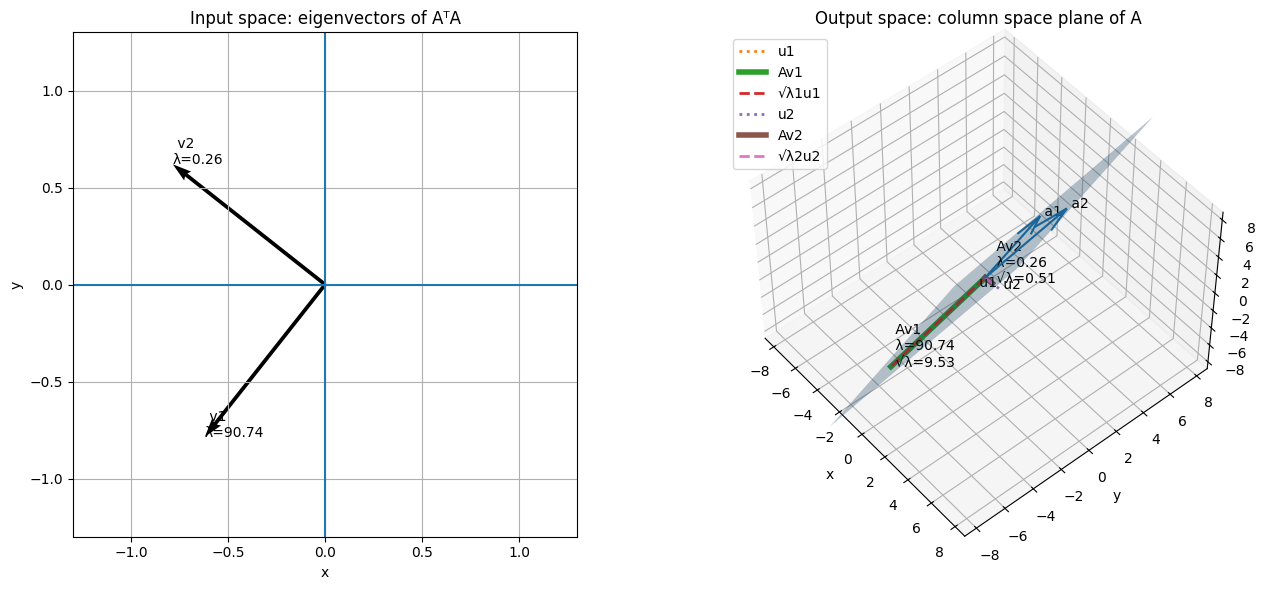

In [8]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

# =========================================================
# eig(A^T A)
# =========================================================
eigenvalues, V = np.linalg.eigh(A.T @ A)

# 큰 eigenvalue 순으로 정렬
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
V = V[:, idx]

# =========================================================
# SVD
# =========================================================
U, s, Vh = np.linalg.svd(A, full_matrices=False)
V_svd = Vh.T

# 부호 맞추기
for i in range(2):
    if np.dot(V[:, i], V_svd[:, i]) < 0:
        V[:, i] *= -1
    if np.dot(U[:, i], A @ V[:, i]) < 0:
        U[:, i] *= -1

# A의 column vectors
a1 = A[:, 0]
a2 = A[:, 1]

fig = plt.figure(figsize=(14, 6))

# =========================================================
# 1. Input space: eigenvectors of A^T A
# =========================================================
ax1 = fig.add_subplot(1, 2, 1)

for i in range(2):
    v = V[:, i]
    lam = eigenvalues[i]

    ax1.quiver(
        0, 0,
        v[0], v[1],
        angles="xy",
        scale_units="xy",
        scale=1
    )
    ax1.text(
        v[0], v[1],
        f" v{i+1}\nλ={lam:.2f}"
    )

ax1.axhline(0)
ax1.axvline(0)
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_aspect("equal")
ax1.grid(True)
ax1.set_title("Input space: eigenvectors of AᵀA")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# =========================================================
# 2. Output space: plane spanned by a1, a2
# =========================================================
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

# -----------------------------------------
# plane: span(a1, a2)
# p(s,t) = s*a1 + t*a2
# -----------------------------------------
s_grid = np.linspace(-1.2, 1.2, 15)
t_grid = np.linspace(-1.2, 1.2, 15)
S, T = np.meshgrid(s_grid, t_grid)

X = S * a1[0] + T * a2[0]
Y = S * a1[1] + T * a2[1]
Z = S * a1[2] + T * a2[2]

ax2.plot_surface(X, Y, Z, alpha=0.3)

# a1, a2
ax2.quiver(0, 0, 0, a1[0], a1[1], a1[2])
ax2.quiver(0, 0, 0, a2[0], a2[1], a2[2])

ax2.text(a1[0], a1[1], a1[2], " a1")
ax2.text(a2[0], a2[1], a2[2], " a2")

# u, Av, sqrt(lambda)u
all_vecs = [a1, a2]

for i in range(2):
    lam = eigenvalues[i]
    sigma = np.sqrt(lam)

    v = V[:, i]
    u = U[:, i]

    Av = A @ v
    sigma_u = sigma * u

    all_vecs.extend([u, Av, sigma_u])

    # u: direction only
    ax2.plot(
        [0, u[0]],
        [0, u[1]],
        [0, u[2]],
        ":",
        linewidth=2,
        label=f"u{i+1}"
    )

    # Av
    ax2.plot(
        [0, Av[0]],
        [0, Av[1]],
        [0, Av[2]],
        linewidth=4,
        label=f"Av{i+1}"
    )

    # sqrt(lambda)u
    ax2.plot(
        [0, sigma_u[0]],
        [0, sigma_u[1]],
        [0, sigma_u[2]],
        "--",
        linewidth=2,
        label=f"√λ{i+1}u{i+1}"
    )

    ax2.text(
        u[0], u[1], u[2],
        f" u{i+1}"
    )

    ax2.text(
        Av[0], Av[1], Av[2],
        f" Av{i+1}\n λ={lam:.2f}\n √λ={sigma:.2f}"
    )

    print(f"\n--- i = {i+1} ---")
    print("v =")
    print(v)
    print("u =")
    print(u)
    print("A @ v =")
    print(Av)
    print("sqrt(lambda) * u =")
    print(sigma_u)
    print("same =", np.allclose(Av, sigma_u))

# 축 범위 자동 조정
all_vecs = np.array(all_vecs)
m = np.max(np.abs(all_vecs)) + 1

ax2.set_xlim(-m, m)
ax2.set_ylim(-m, m)
ax2.set_zlim(-m, m)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_title("Output space: column space plane of A")
ax2.legend()

ax2.view_init(elev=50, azim=-40)

plt.tight_layout()
plt.show()

/Users/br4c3/Projects/linear-algebra-for-machine-and-deep-learning/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/br4c3/Projects/linear-algebra-for-machine-and-deep-learning/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


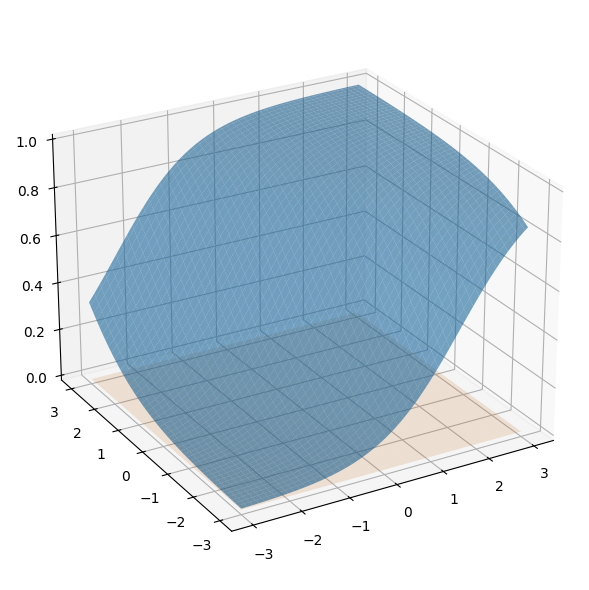

In [11]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

W = np.array(
    [1.2,  0.8]
)
b = 0.5

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)

X1, X2 = np.meshgrid(x1, x2)
Z = sigmoid(W[0] * X1 + W[1] * X2 + b)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X1, X2, Z, alpha=0.6
)

ax.plot_surface(
    X1,
    X2,
    np.zeros_like(Z),
    alpha=0.15
)
ax.view_init(
    elev=25,
    azim=-120
)

plt.tight_layout()
plt.show()